# Машинное обучение, ФКН ВШЭ

## Практическое задание 3. Градиентный спуск своими руками

### Общая информация
Дата выдачи: **01.11.2024**

Мягкий дедлайн: **13.11.24 23:59**

Жесткий дедлайн: **15.11.24 23:59**

### О задании

В данном задании необходимо реализовать обучение линейной регрессии с помощью различных вариантов градиентного спуска.


### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов + 2 балла бонус.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.
Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.


### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате homework-practice-03-gd-Username.ipynb, где Username — ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

**Оценка**: ...

Напомним, что на лекциях и семинарах мы разбирали некоторые подходы к оптимизации функционалов по параметрам. В частности, был рассмотрен градиентный спуск и различные подходы к его реализации — полный градиентный спуск, стохастический градиентный спуск, метод импульса и другие. В качестве модели у нас будет выступать линейная регрессия.

В этом домашнем задании вам предстоит реализовать 4 различных вариации градиентного спуска, написать свою реализацию линейной регресии, сравнить методы градиентного спуска между собой на реальных данных и ещё много чего веселого и интересного!

## Задание 1. Реализация градиентного спуска (3.5 балла)

В этом задании вам предстоит написать собственные реализации различных подходов к градиентному спуску с опорой на подготовленные шаблоны в файле `descents.py`.

**Все реализуемые методы должны быть векторизованы!**

### Лирическое-теоретическое отступление № 1

Основное свойство антиградиента &ndash; он указывает в сторону наискорейшего убывания функции в данной точке. Соответственно, будет логично стартовать из некоторой точки, сдвинуться в сторону антиградиента,
пересчитать антиградиент и снова сдвинуться в его сторону и т.д. Запишем это более формально.

Пусть $w_0$ &ndash; начальный набор параметров (например, нулевой или сгенерированный из некоторого
случайного распределения). Тогда ванильный градиентный спуск состоит в повторении следующих шагов до сходимости:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

### Лирическое-теоретическое отступление № 2

На семинаре про [матрично-векторное дифференцирование](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem03-vector-diff.pdf) вы должны были обсуждать дифференцирование функции потерь MSE в матричном виде.

### Задание 1.0. Градиент MSE в матричном виде (0.02 балла).

Напомним, что функция потерь MSE записывается в матричном виде как:

$$
    Q(w) = \dfrac{1}{\ell} \left( y - Xw \right)^T \left( y - Xw \right)
$$

Выпишите ниже (подсмотрев в семинар или решив самостоятельно) градиент для функции потерь MSE в матричном виде.

$$ d_w \ell Q = dw[(y - Xw)^T(y - Xw)] = d_w[(y - Xw)^T] (y - Xw) + (y - Xw)^T d_w[(y - Xw)] = d_w[(-Xw)^T] (y - Xw) - (y - Xw)^TX d w = - dx w^T X^T (y - Xw) - (y - Xw)^TX dx w = -2 (y - Xw)^TX d_w = 2 (Xw - y)^TX d_w$$

$$
\Longrightarrow 2 X^T(Xw - y) = 0
$$

$$
w = (X^TX)^{-1}X^Ty
$$

### Задание 1.1. Родительский класс BaseDescent (0.5 балла).

Реализуйте функции `calc_loss` (вычисление MSE для переданных $x$ и $y$) и `predict` (предсказание $y_{pred}$ для переданных $x$) в классе `BaseDescent`.

Все вычисления должны быть векторизованы.

### Задание 1.2. Полный градиентный спуск VanillaGradientDescent (0.5 балла).

Реализуйте полный градиентный спуск заполнив пропуски в классе `VanillaGradientDescent` в файле `descents.py`. Для вычисления градиента используйте формулу выше. Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь и далее функция `update_weights` должна возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$. Кроме того, соответственно своему названию, она должна обновлять веса. 

Во всех методах градиентного спуска мы будем использовать следующую формулу для длины шага:

$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

### Лирическое-теоретическое отступление № 3

Как правило, в задачах машинного обучения функционал $Q(w)$ представим в виде суммы $\ell$ функций:

$$
    Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        q_i(w).
$$

В нашем домашнем задании отдельные функции $q_i(w)$ соответствуют ошибкам на отдельных объектах.

Проблема метода градиентного спуска состоит в том, что на каждом шаге необходимо вычислять градиент всей суммы (будем его называть полным градиентом):

$$
    \nabla_w Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        \nabla_w q_i(w).
$$

Это может быть очень трудоёмко при больших размерах выборки. В то же время точное вычисление градиента может быть не так уж необходимо &ndash; как правило, мы делаем не очень большие шаги в сторону антиградиента, и наличие в нём неточностей не должно сильно сказаться на общей траектории.

Оценить градиент суммы функций можно средним градиентов случайно взятого подмножества функций:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}),
$$
где $B$ - это случайно выбранное подмножество индексов.

В этом случае мы получим метод **стохастического градиентного спуска**.

### Задание 1.3. Стохастический градиентный спуск StochasticDescent (0.5 балла).

Реализуйте стохастический градиентный спуск заполнив пропуски в классе `StochasticDescent`. Для оценки градиента используйте формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться гиперпараметром метода, семплируйте индексы для батча объектов с помощью `np.random.randint`.

### Лирическое-теоретическое отступление № 4

Может оказаться, что направление антиградиента сильно меняется от шага к шагу. Например, если линии уровня функционала сильно вытянуты, то из-за ортогональности градиента линиям уровня он будет менять направление на почти противоположное на каждом шаге. Такие осцилляции будут вносить сильный шум в движение, и процесс оптимизации займёт много итераций. Чтобы избежать этого, можно усреднять векторы антиградиента с нескольких предыдущих шагов &ndash; в этом случае шум уменьшится, и такой средний вектор будет указывать в сторону общего направления движения. Введём для этого вектор инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k})
\end{align}

Здесь $\alpha$ &ndash; параметр метода, определяющей скорость затухания градиентов с предыдущих шагов. Разумеется, вместо вектора градиента может быть использована его аппроксимация. Чтобы сделать шаг градиентного спуска, просто сдвинем предыдущую точку на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Заметим, что если по какой-то координате градиент постоянно меняет знак, то в результате усреднения градиентов в векторе инерции эта координата окажется близкой к нулю. Если же по координате знак градиента всегда одинаковый, то величина соответствующей координаты в векторе инерции будет большой, и мы будем делать большие шаги в соответствующем направлении.

### Задание 1.4 Метод Momentum MomentumDescent (0.5 балла).

Реализуйте градиентный спуск с методом инерции заполнив пропуски в классе `MomentumDescent`. Шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ будет являться гиперпараметром метода, но в данном домашнем задании мы зафиксируем её за вас $\alpha = 0.9$.

### Лирическое-теоретическое отступление № 5

Градиентный спуск очень чувствителен к выбору длины шага. Если шаг большой, то есть риск, что мы будем перескакивать через точку минимума; если же шаг маленький, то для нахождения минимума потребуется много итераций. При этом нет способов заранее определить правильный размер шага &ndash; к тому же, схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad предлагается сделать свою длину шага для каждой компоненты вектора параметров. При этом шаг будет тем меньше, чем более длинные шаги мы делали на предыдущих итерациях:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Здесь $\varepsilon$ небольшая константа, которая предотвращает деление на ноль.

В данном методе можно зафксировать длину шага (например, $\eta_k = 0.01$) и не подбирать её в процессе обучения **(обратите внимание, что в данном домашнем задании длина шага не фиксируется)**. Отметим, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю. Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги; если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

У метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт, из-за чего шаги становятся всё медленнее и могут остановиться ещё до того, как достигнут минимум функционала. Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Можно объединить идеи описанных выше методов: накапливать градиенты со всех прошлых шагов для
избежания осцилляций и делать адаптивную длину шага по каждому параметру.

### Задание 1.5. Метод Adam (Adaptive Moment Estimation) (1.5 балла).

Реализуйте градиентный спуск с методом Adam заполнив пропуски в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы за вас.

## Задание 2. Реализация линейной регресии (0.5 балла)

В этом задании вам предстоит написать свою реализацию линейной регресии, обучаемой с использованием градиентного спуска, с опорой на подготовленные шаблоны в файле `linear_regression.py` - **LinearRegression**. По сути линейная регрессия будет оберткой, которая запускает обучение 

Необходимо соблюдать следующие условия:

* Все вычисления должны быть векторизованы;
* Циклы средствами python допускаются только для итераций градиентного спуска;
* В качестве критерия останова необходимо использовать (одновременно):
    * Квадрат евклидовой нормы разности весов на двух соседних итерациях меньше `tolerance`;
    * Разность весов содержит наны;
    * Достижение максимального числа итераций `max_iter`.
* Будем считать, что все данные, которые поступают на вход имеют столбец единичек последним столбцом;
* Веса модели надо обновлять внутри функции `update_weights`, она неспроста так называется
* Чтобы проследить за сходимостью оптимизационного процесса будем использовать `loss_history`, в нём будем хранить значения функции потерь до каждого шага, начиная с нулевого (до первого шага по антиградиенту) и значение функции потерь после оптимизации.

## Задание 3. Проверка кода (0 баллов)

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

import numpy as np

from descents import get_descent
from linear_regression import LinearRegression

In [3]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [4]:
# Descents

descent_config = {
    'descent_name': 'some name that we will replace in the future',
    'kwargs': {
        'dimension': dimension
    }
}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    descent_config['descent_name'] = descent_name
    descent = get_descent(descent_config)

    diff = descent.step(x, y)
    gradient = descent.calc_gradient(x, y)
    predictions = descent.predict(x)

    assert gradient.shape[0] == dimension, f'Gradient failed for descent {descent_name}'
    assert diff.shape[0] == dimension, f'Weights failed for descent {descent_name}'
    assert predictions.shape == y.shape, f'Prediction failed for descent {descent_name}'

In [5]:
# LinearRegression

max_iter = 10
tolerance = 0

descent_config = {
    'descent_name': 'stochastic',
    'kwargs': {
        'dimension': dimension,
        'batch_size': 10
    }
}

regression = LinearRegression(
    descent_config=descent_config,
    tolerance=tolerance,
    max_iter=max_iter
)

regression.fit(x, y)

assert len(regression.loss_history) == max_iter + 1, 'Loss history failed'

Если ваше решение прошло все тесты локально, то теперь пришло время протестировать его в [Яндекс Контесте](https://contest.yandex.ru/contest/70588/).

Для каждой задачи из контеста вставьте ссылку на успешную посылку:

* **VanillaGradientDescent**: https://contest.yandex.ru/contest/70588/run-report/124595279/


* **StochasticDescent**: https://contest.yandex.ru/contest/70588/run-report/124595369/


* **MomentumDescent**: https://contest.yandex.ru/contest/70588/run-report/124595422/


* **Adam**: https://contest.yandex.ru/contest/70588/run-report/124595733/


* **LinearRegression**: https://contest.yandex.ru/contest/70588/run-report/124595748/

## Задание 4. Работа с данными (1 балл)

Мы будем использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас будет являться цена.

* Постройте график распределения целевой переменной в данных, подумайте, нужно ли заменить её на логарифм. Присутствуют ли выбросы в данных с аномальной ценой? Если да, то удалите их из данных.

* Проведите исследование данных:
    * Проанализируйте тип столбцов, постройте графики зависимости целевой переменной от признака, распределения значений признака;
    * Подумайте (и напишите): какие признаки могут быть полезными на основе этих графиков, обработайте выбросы;
    * Подумайте (и напишите): какие трансформации признаков из известных вам будет уместно применить;
    * Разделите полезные признаки на категориальные, вещественные и те, которые не надо предобрабатывать.
* Разделите данные на обучающую, валидационную и тестовую выборки в отношении 8:1:1.

In [6]:
import numpy as np
import pandas as pd  # при желании, можете заменить на polars/pyspark или что угодно, что вам нравится

import matplotlib.pyplot as plt
import seaborn as sns

from descents import get_descent
from linear_regression import LinearRegression

sns.set(style='darkgrid')

In [7]:
data = pd.read_csv('autos.csv')  # разумеется, если вы используете не pandas, это надо поменять

In [8]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

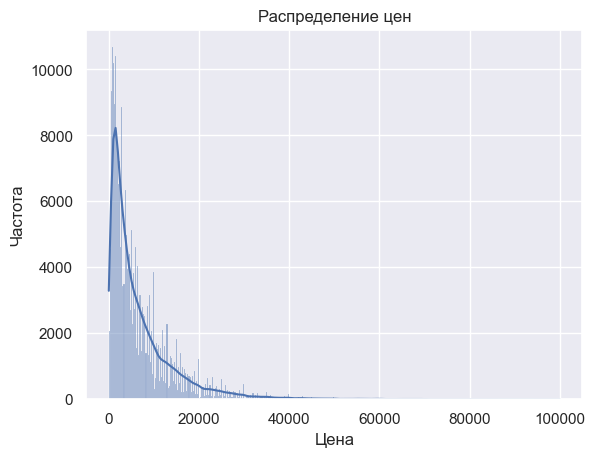

In [9]:
sns.histplot(data['price'], kde=True)
plt.title('Распределение цен')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

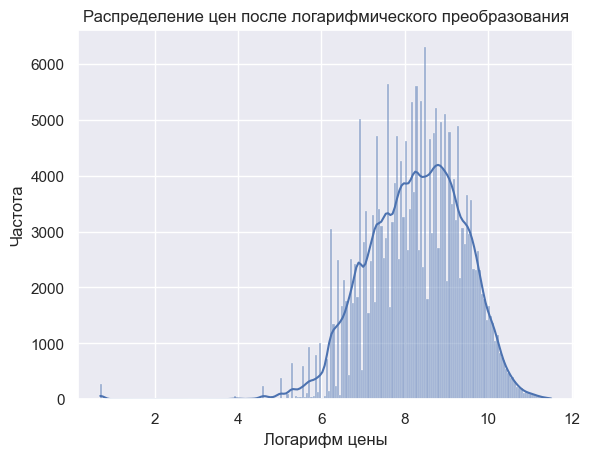

In [10]:
sns.histplot(np.log1p(data['price']), kde=True)
plt.title('Распределение цен после логарифмического преобразования')
plt.xlabel('Логарифм цены')
plt.ylabel('Частота')
plt.show()

In [11]:
data['log_price'] = np.log1p(data['price'])

In [12]:
data = data[data['log_price'] >= 4]

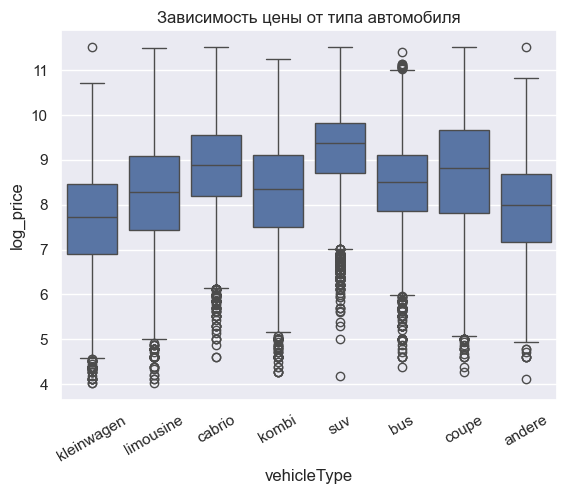

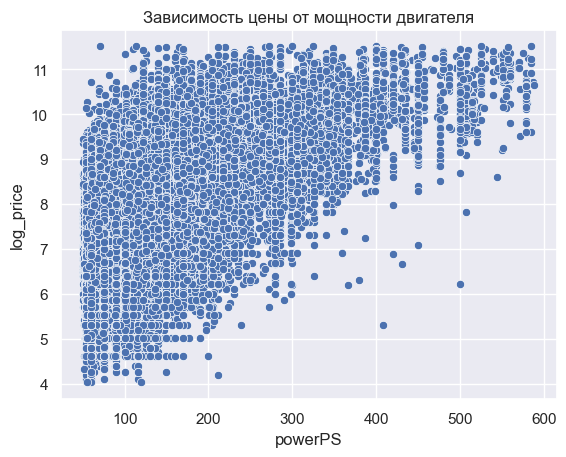

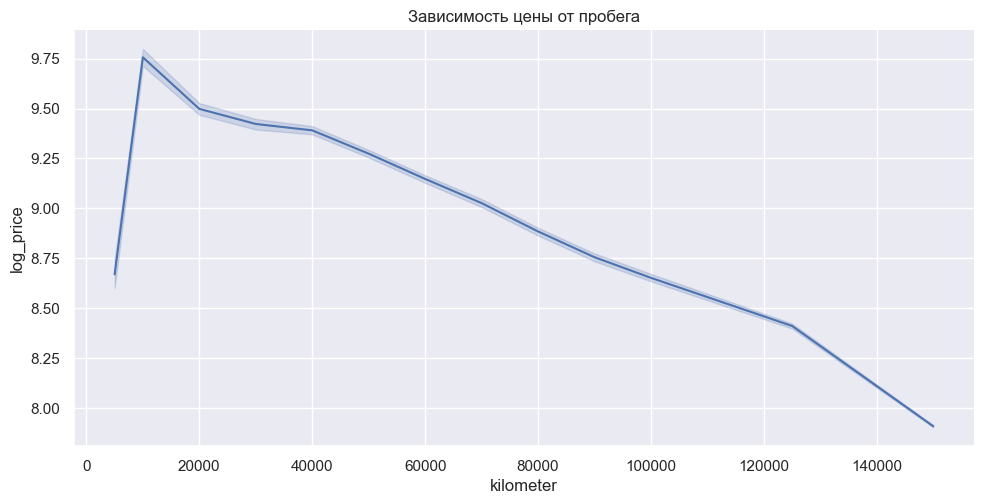

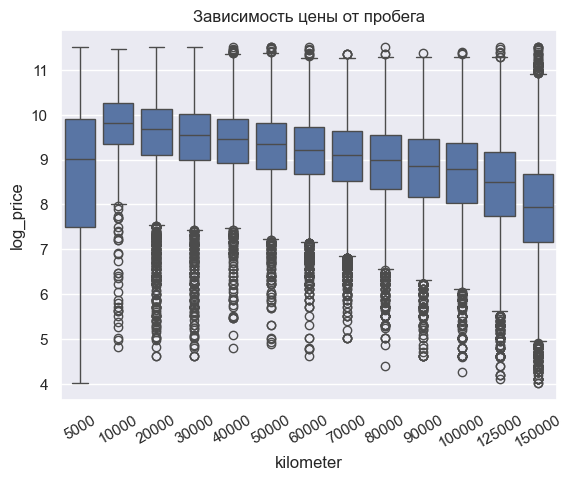

In [13]:
sns.boxplot(x='vehicleType', y='log_price', data=data)
plt.xticks(rotation=30)
plt.title('Зависимость цены от типа автомобиля')
plt.show()

sns.scatterplot(x='powerPS', y='log_price', data=data)
plt.title('Зависимость цены от мощности двигателя')
plt.show()

sns.relplot(x='kilometer', y='log_price', data=data, kind='line', aspect=2)
plt.title('Зависимость цены от пробега')
plt.show()

sns.boxplot(x='kilometer', y='log_price', data=data)
plt.title('Зависимость цены от пробега')
plt.xticks(rotation=30)
plt.show()


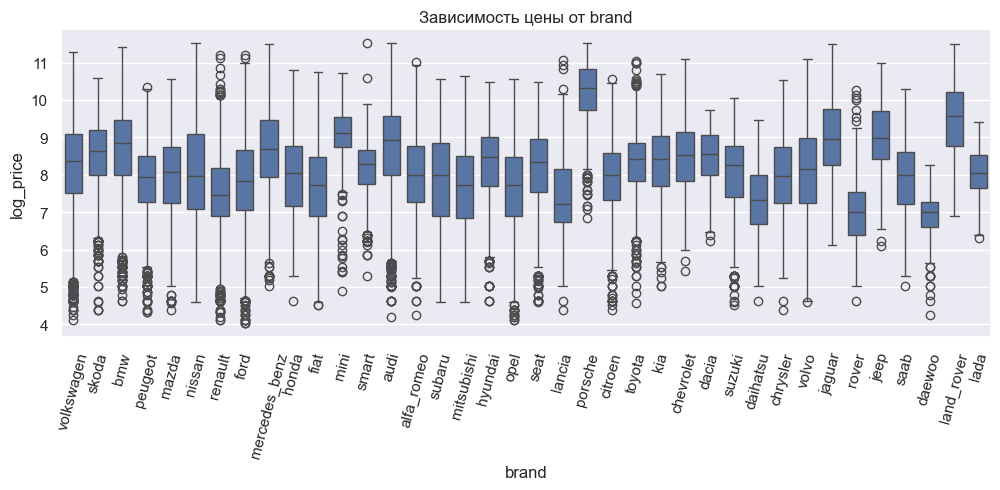

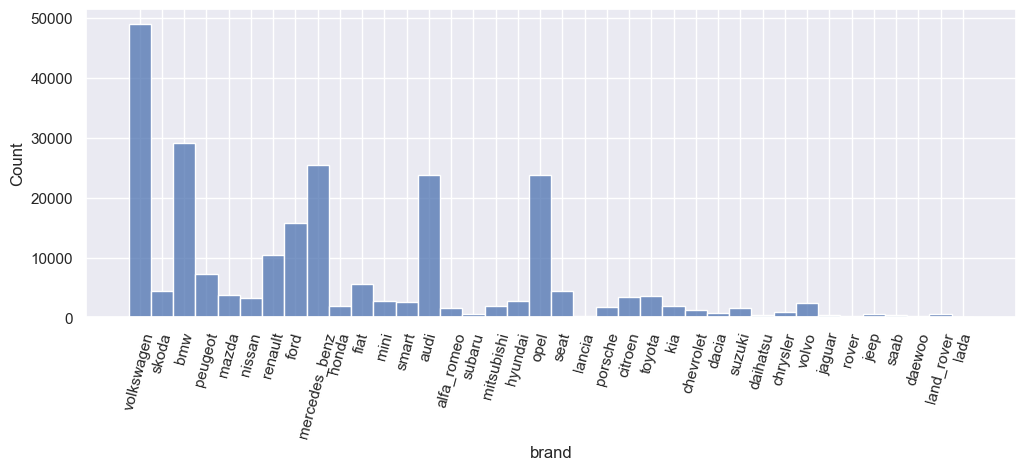

In [14]:
plt.figure(figsize=(12, 4)) 
sns.boxplot(x='brand', y='log_price', data=data, width=0.7)
plt.title('Зависимость цены от brand')
plt.xticks(rotation=75)
plt.show()

plt.figure(figsize=(12, 4)) 
sns.histplot(data=data['brand'])
plt.xticks(rotation=75)
plt.show()

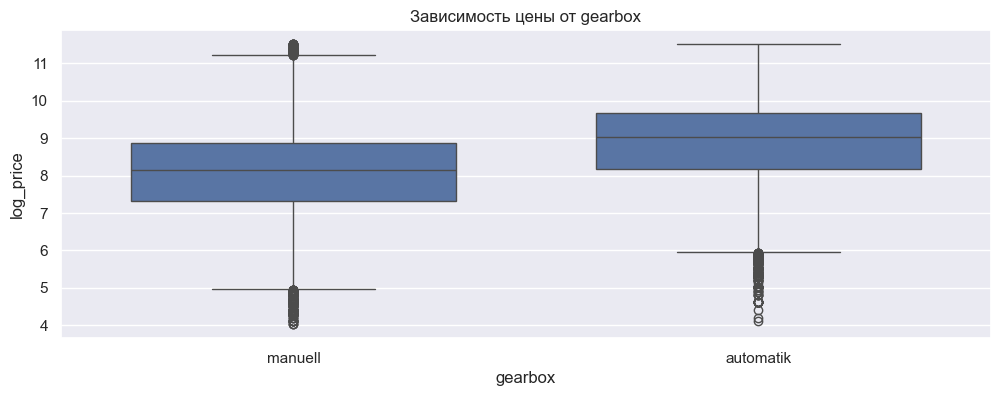

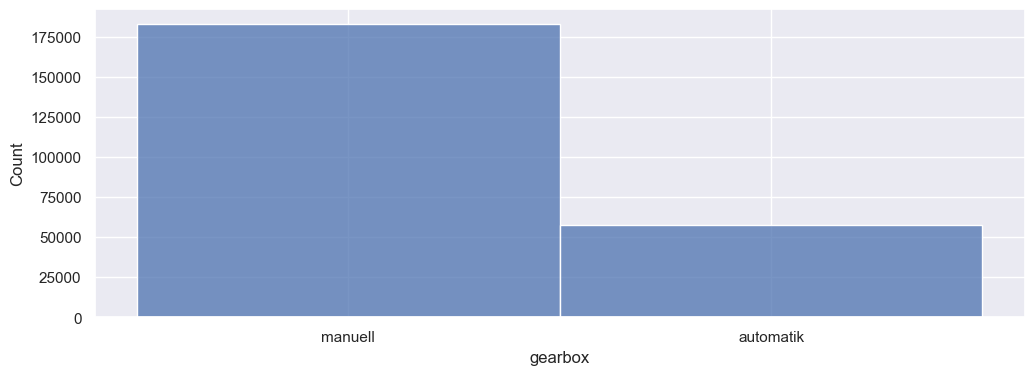

In [15]:
plt.figure(figsize=(12, 4)) 
sns.boxplot(x='gearbox', y='log_price', data=data, width=0.7)
plt.title('Зависимость цены от gearbox')
plt.show()

plt.figure(figsize=(12, 4)) 
sns.histplot(data=data['gearbox'])
plt.show()

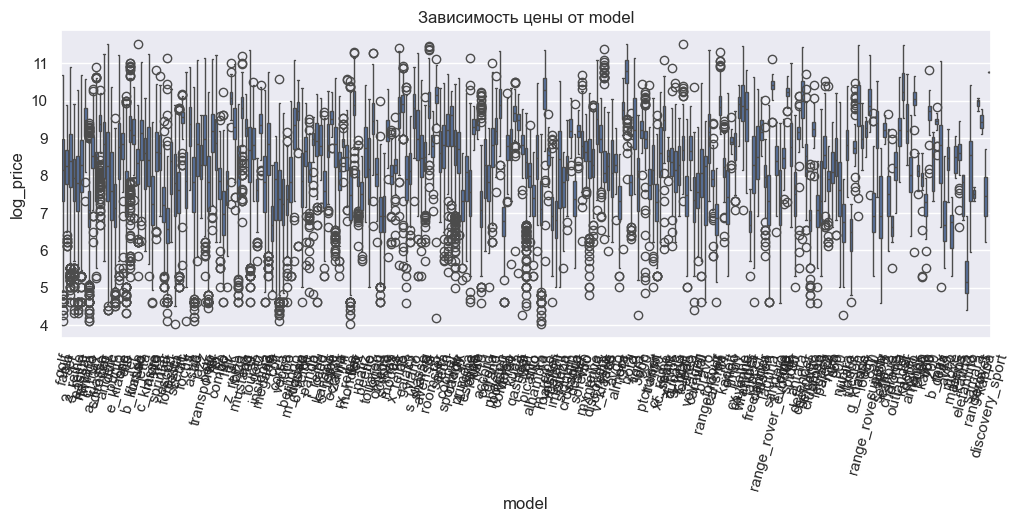

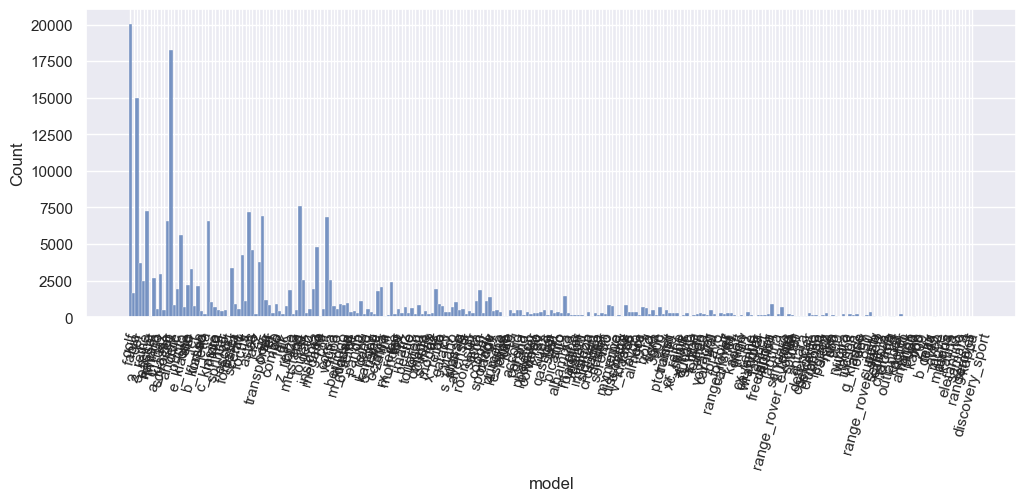

In [16]:
plt.figure(figsize=(12, 4)) 
sns.boxplot(x='model', y='log_price', data=data, width=0.7)
plt.title('Зависимость цены от model')
plt.xticks(rotation=75)
plt.show()

plt.figure(figsize=(12, 4)) 
sns.histplot(data=data['model'])
plt.xticks(rotation=75)
plt.show()

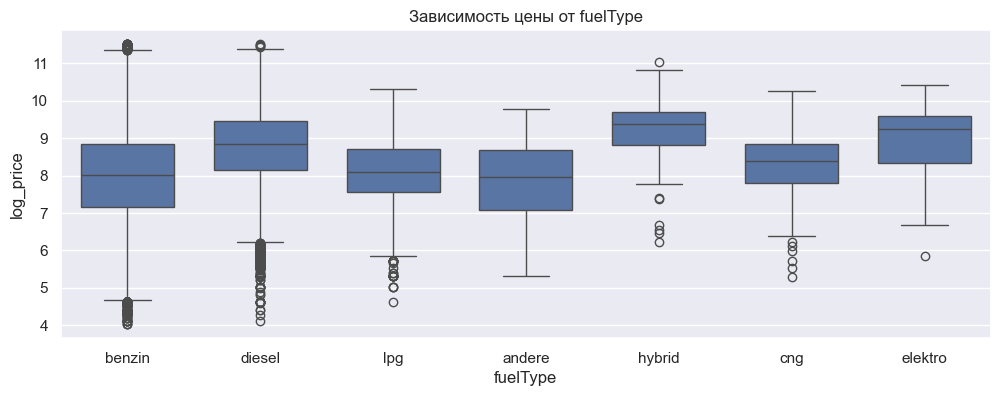

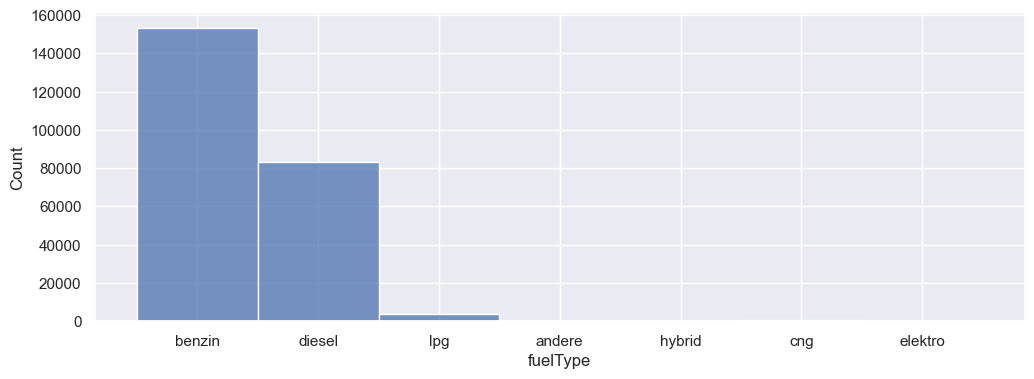

In [17]:
plt.figure(figsize=(12, 4)) 
sns.boxplot(x='fuelType', y='log_price', data=data, width=0.7)
plt.title('Зависимость цены от fuelType')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(12, 4)) 
sns.histplot(data=data['fuelType'])
plt.xticks(rotation=0)
plt.show()

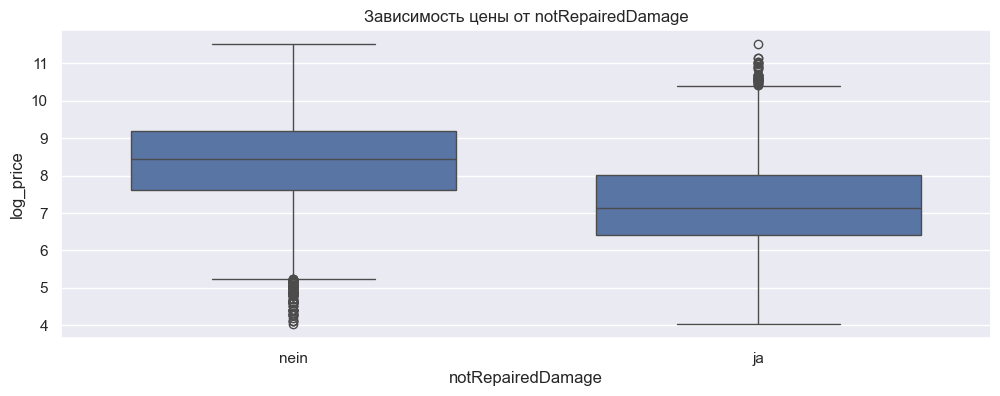

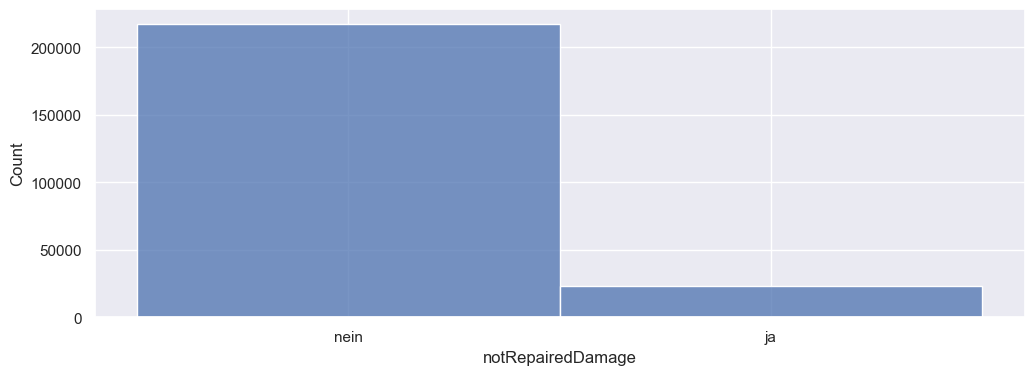

In [18]:
plt.figure(figsize=(12, 4)) 
sns.boxplot(x='notRepairedDamage', y='log_price', data=data, width=0.7)
plt.title('Зависимость цены от notRepairedDamage')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(12, 4)) 
sns.histplot(data=data['notRepairedDamage'])
plt.xticks(rotation=0)
plt.show()

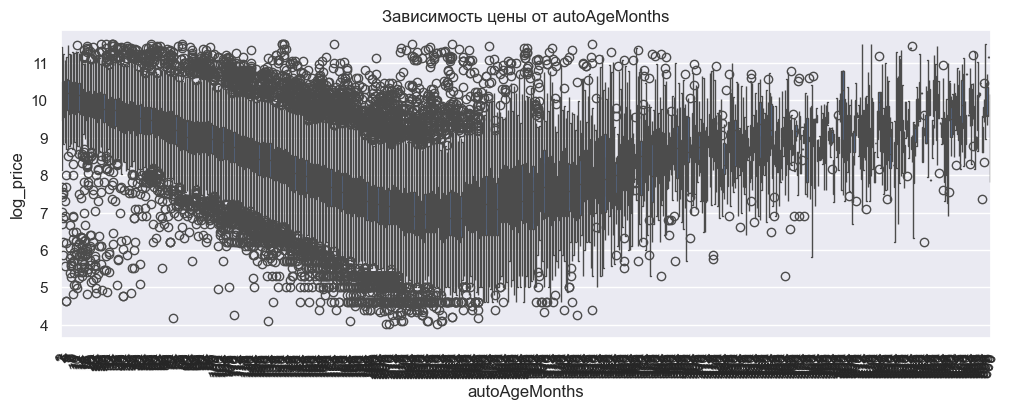

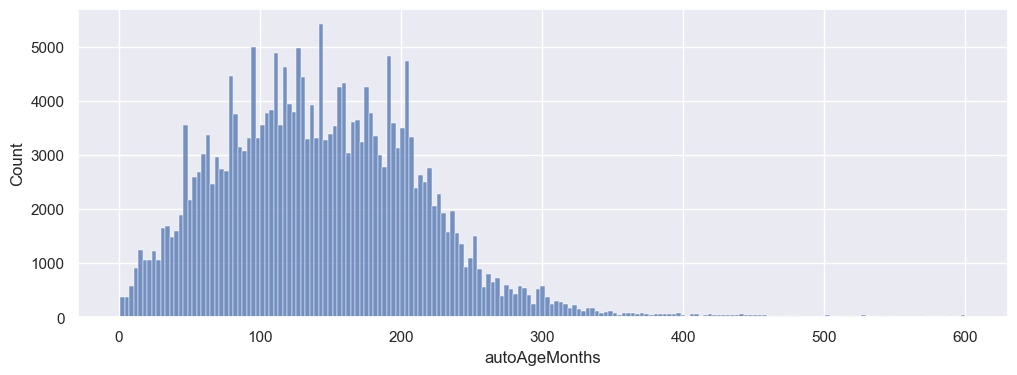

In [19]:
plt.figure(figsize=(12, 4)) 
sns.boxplot(x='autoAgeMonths', y='log_price', data=data, width=0.7)
plt.title('Зависимость цены от autoAgeMonths')
plt.xticks(rotation=75)
plt.show()

plt.figure(figsize=(12, 4)) 
sns.histplot(data=data['autoAgeMonths'])
plt.xticks(rotation=0)
plt.show()

In [20]:
model_drop = data.groupby('model').size().sort_values()
model_drop.head(15)

model
discovery_sport     1
samara              2
serie_2             3
serie_3             3
rangerover          3
elefantino          4
i3                  5
kalina              5
200                 9
kappa              10
move               11
materia            12
charade            13
musa               17
9000               21
dtype: int64

In [21]:
data = data[(data['model'] != 'discovery_sport') & (data['model'] != 'samara') & (data['model'] != 'serie_2') 
            & (data['model'] != 'serie_3') & (data['model'] != 'rangerover') & (data['model'] != 'elefantino')
            & (data['model'] != 'i3') & (data['model'] != 'kalina') & (data['model'] != '200')
            & (data['model'] != 'kappa') & (data['model'] != 'move') & (data['model'] != 'materia')
            & (data['model'] != 'charade') & (data['model'] != 'musa')]

In [22]:
data = data[data['autoAgeMonths'] <= 350]

In [23]:
data['fuelType'].value_counts()

fuelType
benzin     151082
diesel      82837
lpg          3655
cng           428
hybrid        195
andere         31
elektro        28
Name: count, dtype: int64

In [24]:
data.loc[:, 'fuel_more'] = 1
data.loc[(data['fuelType'] == 'benzin') | (data['fuelType'] == 'diesel'), 'fuel_more'] = 0

In [25]:
categorical = ['gearbox', 'fuelType', 'notRepairedDamage', 'brand', 'model', 'vehicleType']
numeric = ['kilometer', 'autoAgeMonths', 'powerPS']
other = ['fuel_more']

In [26]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['log_price']

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])

x = column_transformer.fit_transform(x)

In [28]:
from sklearn.model_selection import train_test_split
X_train_big, X_test, y_train_big, y_test = train_test_split(x.toarray(), np.array(data['log_price']), test_size=0.1, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_big, y_train_big, test_size=1/9, random_state=42)

## Задание 5. Сравнение методов градиентного спуска (2 балла)

В этом задании вам предстоит сравнить методы градиентного спуска на подготовленных вами данных из предыдущего задания.

### Задание 5.1. Подбор оптимальной длины шага (1 балл)

Подберите по валидационной выборке наилучшую длину шага $\lambda$ для каждого метода с точки зрения ошибки. Для этого сделайте перебор по логарифмической сетке. Для каждого метода посчитайте ошибку на обучающей и тестовой выборках, посчитайте качество по метрике $R^2$, сохраните количество итераций до сходимости.

Все параметры кроме `lambda_` стоит выставить равным значениям по умолчанию.

In [ ]:
X_train

In [49]:
from sklearn.metrics import r2_score, mean_squared_error


lambdas = np.hstack((np.array([0]), np.logspace(-5, 1, 10)))
best_lambdas = {}
    
for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    dict_ = {}
    for l in lambdas:
        descent_config = {
            'descent_name': descent_name,
            'kwargs': {
                'dimension': X_train.shape[1],
                'lambda_': l
            }
        }

        regression = LinearRegression(
            descent_config=descent_config,
        )

        regression.fit(X_train, y_train)
        y_pred = regression.predict(X_val)
        error = mean_squared_error(y_pred, y_val)
        dict_[error] = l
    print(dict_)
    best_lambdas[descent_name] = dict_[min(dict_.keys(), key=abs)]
        
best_lambdas

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:78: RuntimeWarning: overflow encountered in square
  return np.mean((x @ self.w - y) ** 2)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:501: RuntimeWarning: overflow encountered in square
  output_errors = np.average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


{22.12452447550222: 0.0, 24.90233887093278: 1e-05, 24.75929861824841: 4.641588833612782e-05, 29.641976489547485: 0.00021544346900318823, 30.735270447484996: 0.001, 16.123595618666073: 0.004641588833612777, 1.7493032953000662: 0.021544346900318822, 0.664049604661189: 0.1, 0.32102660557686497: 0.46415888336127725, 50.39514637185102: 2.154434690031882, inf: 10.0}


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:78: RuntimeWarning: overflow encountered in square
  return np.mean((x @ self.w - y) ** 2)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:501: RuntimeWarning: overflow encountered in square
  output_errors = np.average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


{28.726260879673664: 0.0, 19.36762480871614: 1e-05, 27.285378729416195: 4.641588833612782e-05, 24.466502714328147: 0.00021544346900318823, 22.56930285802043: 0.001, 12.961381239544842: 0.004641588833612777, 2.2238362620654137: 0.021544346900318822, 0.6927224706762115: 0.1, 0.28455328727157275: 0.46415888336127725, 3.593494205883041e+28: 2.154434690031882, inf: 10.0}


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:78: RuntimeWarning: overflow encountered in square
  return np.mean((x @ self.w - y) ** 2)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:501: RuntimeWarning: overflow encountered in square
  output_errors = np.average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


{26.940105107481415: 0.0, 34.726674503284215: 1e-05, 35.81880337748787: 4.641588833612782e-05, 22.51340163361258: 0.00021544346900318823, 4.766208667033229: 0.001, 0.6424233233092775: 0.004641588833612777, 0.6627672571818134: 0.021544346900318822, 0.29583121159776504: 0.1, 0.22555885396694722: 0.46415888336127725, 10.218473378971755: 2.154434690031882, inf: 10.0}
{32.378674048340486: 0.0, 21.34756368651422: 1e-05, 23.752355585732698: 4.641588833612782e-05, 28.62089957701596: 0.00021544346900318823, 22.264989593492967: 0.001, 19.47316541424307: 0.004641588833612777, 1.884964583190924: 0.021544346900318822, 0.21555433373172064: 0.1, 0.20066848375426316: 0.46415888336127725, 0.2001525998903215: 2.154434690031882, 0.19962461318580543: 10.0}


{'full': 0.46415888336127725,
 'stochastic': 0.46415888336127725,
 'momentum': 0.46415888336127725,
 'adam': 10.0}

In [74]:
loss_history = {}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    descent_config = {
        'descent_name': descent_name,
        'kwargs': {
            'dimension': X_train_big.shape[1],
            'lambda_': best_lambdas[descent_name]
        }
    }

    regression = LinearRegression(
        descent_config=descent_config,
    )

    regression.fit(X_train_big, y_train_big)
    loss_history[descent_name] = regression.loss_history
    y_pred = regression.predict(X_test)
    error = r2_score(y_pred, y_test)
    train_pred = regression.predict(X_train)
    error1 = r2_score(train_pred, y_train)
    print(descent_name)
    print("R^2 Score_train:", error)
    print("R^2 Score_test:", error1)
    print("Iteration:", regression.descent.lr.iteration)
    print()
    print()

full
R^2 Score_train: 0.6818673164432989
R^2 Score_test: 0.6889926065862617
Iteration: 41


stochastic
R^2 Score_train: 0.7042215641722795
R^2 Score_test: 0.7080592456042477
Iteration: 110


momentum
R^2 Score_train: 0.7785720066635777
R^2 Score_test: 0.7849389488348384
Iteration: 88


adam
R^2 Score_train: 0.8004210465313126
R^2 Score_test: 0.807557387762322
Iteration: 156




### Задание 5.2. Сравнение методов (1 балла) 

Постройте график зависимости ошибки на обучающей выборке от номера итерации (все методы на одном графике).

Посмотрите на получившиеся результаты (таблички с метриками и график). Сравните методы между собой.

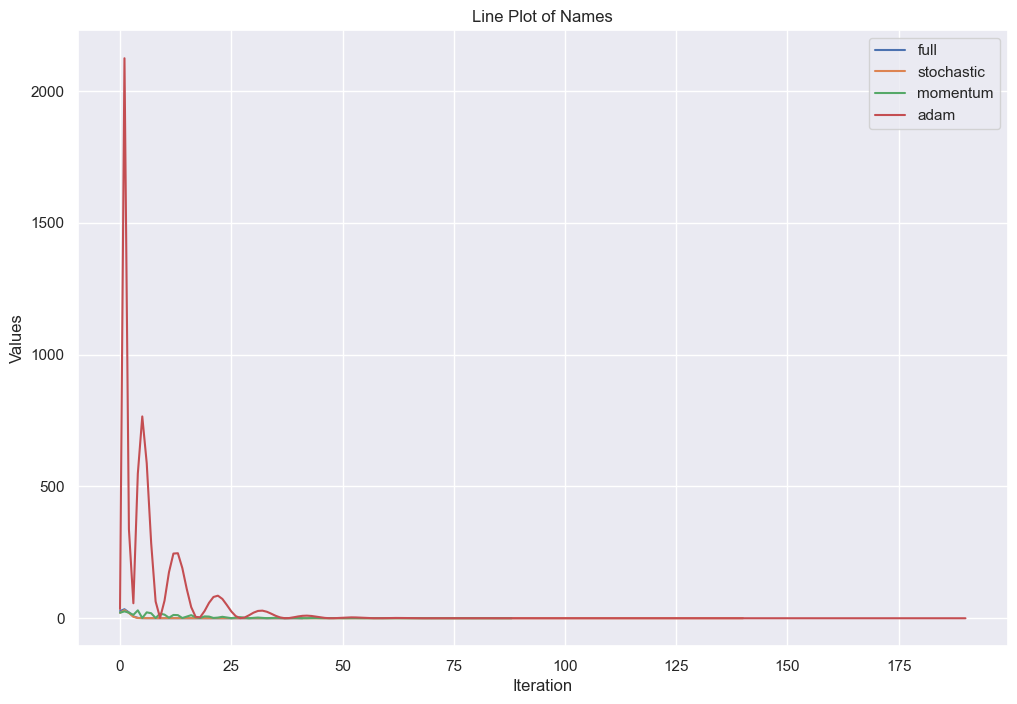

In [60]:
plt.figure(figsize=(12, 8)) 

for name, values in loss_history.items():
    plt.plot(values, label=name)

plt.legend()

plt.title('Line Plot of Names')
plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

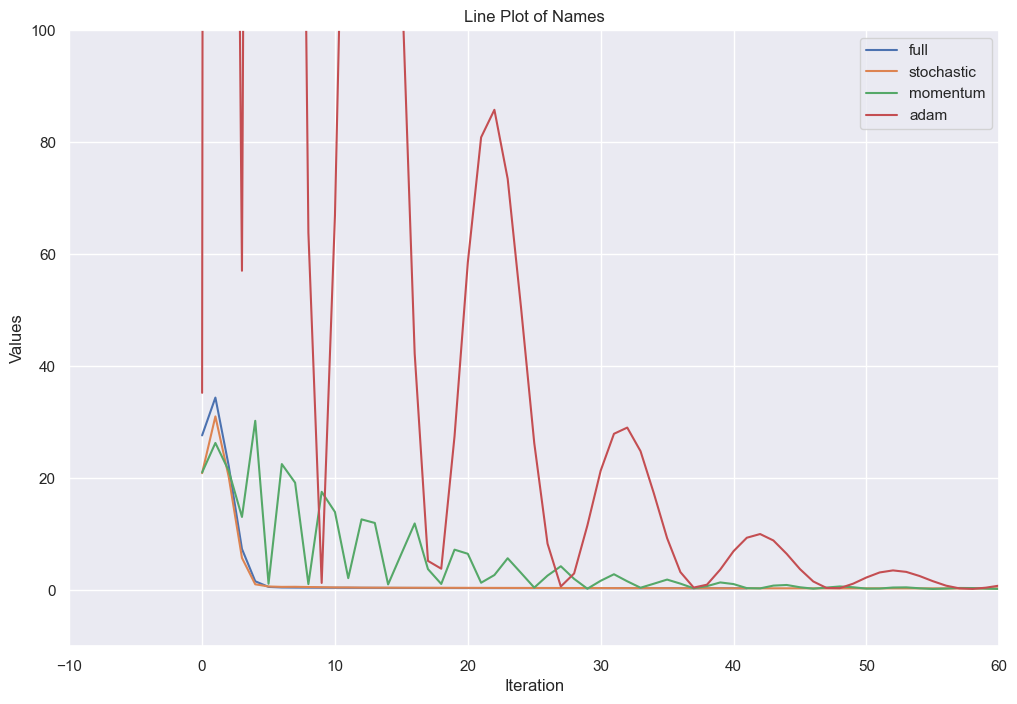

In [63]:
plt.figure(figsize=(12, 8)) 

for name, values in loss_history.items():
    plt.plot(values, label=name)
plt.ylim(-10, 100)
plt.xlim(-10, 60)
plt.legend()

plt.title('Line Plot of Names')
plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

Все методы показали хорошие результаты. Full и Stohastic быстрее сошлись чем Adam и Momentum.

## Задание 6. Стохастический градиентный спуск и размер батча (1 балл)

В этом задании вам предстоит исследовать влияние размера батча на работу стохастического градиентного спуска. 

* Сделайте по несколько запусков (например, k = 10) стохастического градиентного спуска на обучающей выборке для каждого размера батча из перебираемого списка. Замерьте время в секундах и количество итераций до сходимости. Посчитайте среднее этих значений для каждого размера батча.
* Постройте график зависимости количества шагов до сходимости от размера батча. _(под сходимостью понимается достижение критерия останова)_
* Постройте график зависимости времени до сходимости от размера батча.

Посмотрите на получившиеся результаты. Какие выводы можно сделать про подбор размера батча для стохастического градиентного спуска?

In [66]:
import time

batch_sizes = np.arange(5, 500, 10)


batch_time = {}
batch_iter = {}
for batch in batch_sizes:
    time_ = []
    iter_ = []
    for _ in range(10):
        descent_config = {
            'descent_name': 'stochastic',
            'kwargs': {
                'dimension': X_train_big.shape[1],
                'lambda_': best_lambdas['stochastic'],
                'batch_size': batch
            }
        }

        regression = LinearRegression(
            descent_config=descent_config
        )
        
        begin = time.time()
        regression.fit(X_train_big, y_train_big)
        time_.append(time.time() - begin)
        iter_.append(regression.descent.lr.iteration)
    batch_time[batch] = np.mean(time_)
    batch_iter[batch] = np.mean(iter_)

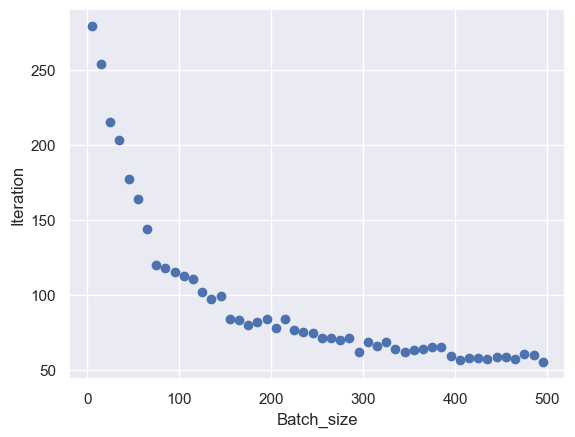

In [70]:
plt.figure() 

plt.scatter(x=list(batch_iter.keys()), y=list(batch_iter.values()))

plt.xlabel('Batch_size')
plt.ylabel('Iteration')

plt.show()

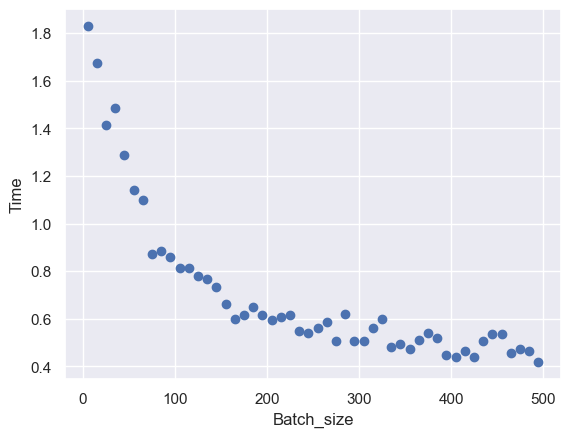

In [71]:
plt.figure() 

plt.scatter(x=list(batch_time.keys()), y=list(batch_time.values()))

plt.xlabel('Batch_size')
plt.ylabel('Time')

plt.show()

Чем больше размера батча, тем мньше времени и итерации 

## Задание 7. Регуляризация (1 балл)

В этом задании вам предстоит исследовать влияние регуляризации на работу различных методов градиентного спуска. Напомним, регуляризация - это добавка к функции потерь, которая штрафует за норму весов. Мы будем использовать l2 регуляризацию, таким образом функция потерь приобретает следующий вид:

$$
    Q(w) = \dfrac{1}{\ell} \sum\limits_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} \| w \|^2
$$

Допишите класс **BaseDescentReg** в файле `descents.py`.

Протестируйте ваше решение в контесте.

Вставьте ссылку на успешную посылку:

* **BaseDescentReg**: https://contest.yandex.ru/contest/70588/run-report/124711866/

Найдите лучшие параметры обучения с регуляризацией аналогично 5 заданию. Будем подбирать длину шага $\lambda$ (`lambda_`) и коэффициент регуляризации $\mu$ (`mu`).

Сравните для каждого метода результаты с регуляризацией и без регуляризации (нужно опять сохранить ошибку и качество по метрике $R^2$ на обучающей и тестовой выборках и количество итераций до сходимости).

Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации (всего должно получиться 4 графика).

Посмотрите на получившиеся результаты. Какие можно сделать выводы, как регуляризация влияет на сходимость? Как изменилось качество на обучающей выборке? На тестовой? Чем вы можете объяснить это?

In [80]:
lambdas = np.hstack((np.array([0]), np.logspace(-1, 0, 5)))
mus = np.hstack((np.array([0]), np.logspace(-1, 0, 5)))


best_lambdas_mu = {}
for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    dict_ = {}
    for l in lambdas:
        for mu in mus:
            descent_config = {
                'descent_name': descent_name,
                'regularized': True,
                'kwargs': {
                    'dimension': X_train.shape[1],
                    'lambda_': l,
                    'mu': mu
                }
            }

            regression = LinearRegression(
                descent_config=descent_config
            )

            regression.fit(X_train, y_train)
            y_pred = regression.predict(X_val)
            error = mean_squared_error(y_pred, y_val)
            dict_[error] = (l, mu)

    best_lambdas_mu[descent_name] = dict_[min(dict_.keys(), key=abs)]
        
best_lambdas_mu

{'full': (1.0, 0.0),
 'stochastic': (0.5623413251903491, 0.0),
 'momentum': (1.0, 0.0),
 'adam': (0.5623413251903491, 0.0)}

In [81]:
loss_history_reg = {}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    
    descent_config = {
        'descent_name': descent_name,
        'kwargs': {
            'dimension': X_train_big.shape[1],
            'lambda_': best_lambdas[descent_name]
        }
    }

    regression = LinearRegression(
        descent_config=descent_config,
    )

    regression.fit(X_train_big, y_train_big)
    y_pred = regression.predict(X_test)
    error = r2_score(y_pred, y_test)
    train_pred = regression.predict(X_train)
    error1 = r2_score(train_pred, y_train)
    print(descent_name)
    print("R^2 Score_train:", error)
    print("R^2 Score_test:", error1)
    print("Iteration:", regression.descent.lr.iteration)
    print()
    
    
    descent_config = {
        'descent_name': descent_name,
        'regularized': True,
        'kwargs': {
            'dimension': X_train_big.shape[1],
            'lambda_': best_lambdas_mu[descent_name][0],
            'mu': best_lambdas_mu[descent_name][1]
        }
    }

    regression = LinearRegression(
        descent_config=descent_config
    )

    regression.fit(X_train_big, y_train_big)
    loss_history_reg[descent_name] = regression.loss_history
    y_pred = regression.predict(X_test)
    error = r2_score(y_pred, y_test)
    train_pred = regression.predict(X_train)
    error1 = r2_score(train_pred, y_train)
    print(descent_name)
    print("R^2 Score_train_reg:", error)
    print("R^2 Score_test_reg:", error1)
    print("Iteration:", regression.descent.lr.iteration)
    print("---------------------------------------------------")
    

full
R^2 Score_train: 0.6893927653563896
R^2 Score_test: 0.6990048365226971
Iteration: 37

full
R^2 Score_train_reg: 0.7187840201796629
R^2 Score_test_reg: 0.7267735080998986
Iteration: 54
---------------------------------------------------
stochastic
R^2 Score_train: 0.7281606713883091
R^2 Score_test: 0.7352126237176719
Iteration: 121

stochastic
R^2 Score_train_reg: 0.7211449857237154
R^2 Score_test_reg: 0.7293854175037937
Iteration: 227
---------------------------------------------------
momentum
R^2 Score_train: 0.7797944455099671
R^2 Score_test: 0.7861501338887282
Iteration: 88

momentum
R^2 Score_train_reg: 0.7789546773329287
R^2 Score_test_reg: 0.786096499452553
Iteration: 106
---------------------------------------------------
adam
R^2 Score_train: 0.7997105238491697
R^2 Score_test: 0.8064810423659708
Iteration: 143

adam
R^2 Score_train_reg: 0.7991001981126884
R^2 Score_test_reg: 0.8063829145358605
Iteration: 153
---------------------------------------------------


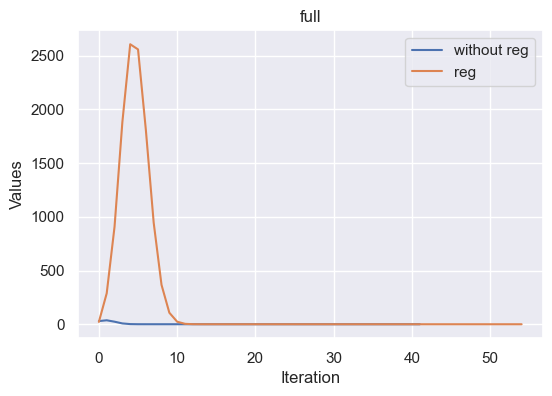

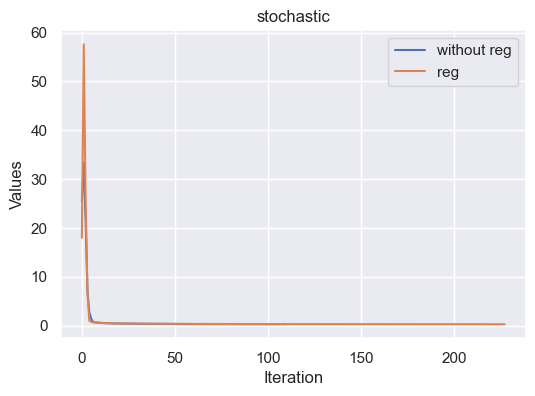

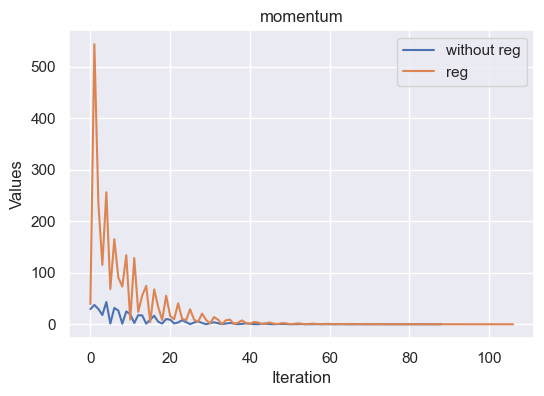

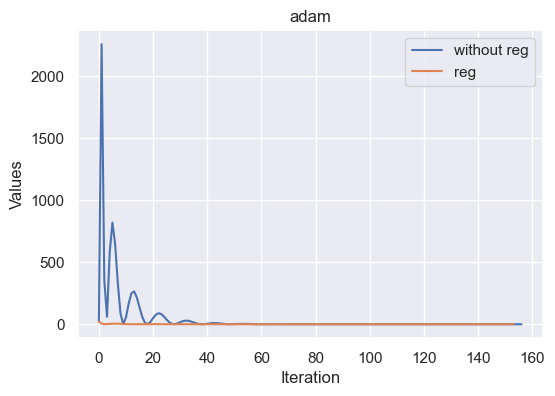

In [84]:

for name in ['full', 'stochastic', 'momentum', 'adam']:
    plt.figure(figsize=(6, 4)) 
    plt.plot(loss_history[name], label="without reg")
    plt.plot(loss_history_reg[name], label='reg')
    
    plt.legend()

    plt.title(name)
    plt.xlabel('Iteration')
    plt.ylabel('Values')

    plt.show()


Количество итераций везде увеличился, качество стало немножко лучше. В начале обучения у регуляризации сильные колебания, но со временем все становится лучше.

## Задание 8. Альтернативная функция потерь (1 балл)

В этом задании вам предстоит использовать другую функцию потерь для нашей задачи регрессии. В качестве функции потерь мы выбрали **Log-Cosh**:

$$
    L(y, a)
    =
    \log\left(\cosh(a - y)\right).
$$

Самостоятельно продифференцируйте данную функцию потерь чтобы найти её градиент _(требуется показать не только результат, но и промежуточные вычисления)_:


$$
\frac{\partial L}{\partial w} = \frac{1}{\cosh(Xw - y)} \cdot \frac{\partial \cosh(Xw - y)}{\partial w}
=\frac{X^T \cdot \sinh(Xw - y)}{\cosh(Xw - y)}
=X^T \cdot \tanh(Xw - y)
$$

Программно реализуйте градиентный спуск с данной функцией потерь в файле `descents.py`, обучите все четыре метода (без регуляризации) аналогично 5 заданию, сравните их качество с четырьмя методами из 5 задания.

Пример того, как можно запрограммировать использование нескольких функций потерь внутри одного класса градиентного спуска:


```python
from enum import auto
from enum import Enum

import numpy as np

class LossFunction(Enum):
    MSE = auto()
    MAE = auto()
    LogCosh = auto()
    Huber = auto()

...
class BaseDescent:
    def __init__(self, loss_function: LossFunction = LossFunction.MSE):
        self.loss_function: LossFunction = loss_function

    def calc_gradient(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        if self.loss_function is LossFunction.MSE:
            return ...
        elif self.loss_function is LossFunction.LogCosh:
            return ...
...

```

In [31]:
%load_ext autoreload

%autoreload 2

import numpy as np

from descents import get_descent
from linear_regression import LinearRegression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
from descents import LossFunction
from sklearn.metrics import r2_score, mean_squared_error

lambdas = np.hstack((np.array([0]), np.logspace(-6, 1, 10)))
best_lambdas_logcosh = {}
    
for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    dict_ = {}
    for l in lambdas:
        descent_config = {
            'descent_name': descent_name,
            'kwargs': {
                'dimension': X_train.shape[1],
                'lambda_': l,
                'loss_function': LossFunction.LogCosh
            }
        }

        regression = LinearRegression(
            descent_config=descent_config,
        )

        regression.fit(X_train, y_train)
        y_pred = regression.predict(X_val)
        error = mean_squared_error(y_pred, y_val)
        dict_[error] = l

    best_lambdas_logcosh[descent_name] = dict_[min(dict_.keys(), key=abs)]
        
best_lambdas_logcosh

/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:81: RuntimeWarning: overflow encountered in cosh
  return np.mean(np.log(np.cosh(x @ self.w - y)))
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:81: RuntimeWarning: overflow encountered in cosh
  return np.mean(np.log(np.cosh(x @ self.w - y)))
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:81: RuntimeWarning: overflow encountered in cosh
  return np.mean(np.log(np.cosh(x @ self.w - y)))
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:81: RuntimeWarning: overflow encountered in cosh
  return np.mean(np.log(np.cosh(x @ self.w - y)))
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:81: RuntimeWarning: overflow encountered in cosh
  return np.mean(np.log(np.cosh(x @ self.w - y)))
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:81: RuntimeWarning: overflow encountered in cosh
  return np.mean(np.log(np.cosh(x @ self.w - y)))
/Users/tanpeter/Desktop/ML/ML_Homework/HW3/descents.py:81: RuntimeWarning: o

{'full': 3.5938136638046256e-05,
 'stochastic': 0.04641588833612782,
 'momentum': 3.5938136638046256e-05,
 'adam': 10.0}

In [44]:
loss_history_logcosh = {}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    descent_config = {
        'descent_name': descent_name,
        
        'kwargs': {
            'dimension': X_train_big.shape[1],
            'lambda_': best_lambdas_logcosh[descent_name],
            'loss_function': LossFunction.LogCosh
        }
    }

    regression = LinearRegression(
        descent_config=descent_config,
    )

    regression.fit(X_train_big, y_train_big)
    loss_history_logcosh[descent_name] = regression.loss_history
    y_pred = regression.predict(X_test)
    error = r2_score(y_pred, y_test)
    train_pred = regression.predict(X_train)
    error1 = r2_score(train_pred, y_train)
    print(descent_name)
    print("R^2 Score_train:", error)
    print("R^2 Score_test:", error1)
    print("Iteration:", regression.descent.lr.iteration)
    print()
    print()

full
R^2 Score_train: 0.7564634758716229
R^2 Score_test: 0.7641885844666152
Iteration: 154


stochastic
R^2 Score_train: 0.7525196210988733
R^2 Score_test: 0.7590897645787318
Iteration: 300


momentum
R^2 Score_train: 0.7930607511706118
R^2 Score_test: 0.8002372209328219
Iteration: 300


adam
R^2 Score_train: 0.8032120428671015
R^2 Score_test: 0.8098768025058007
Iteration: 161




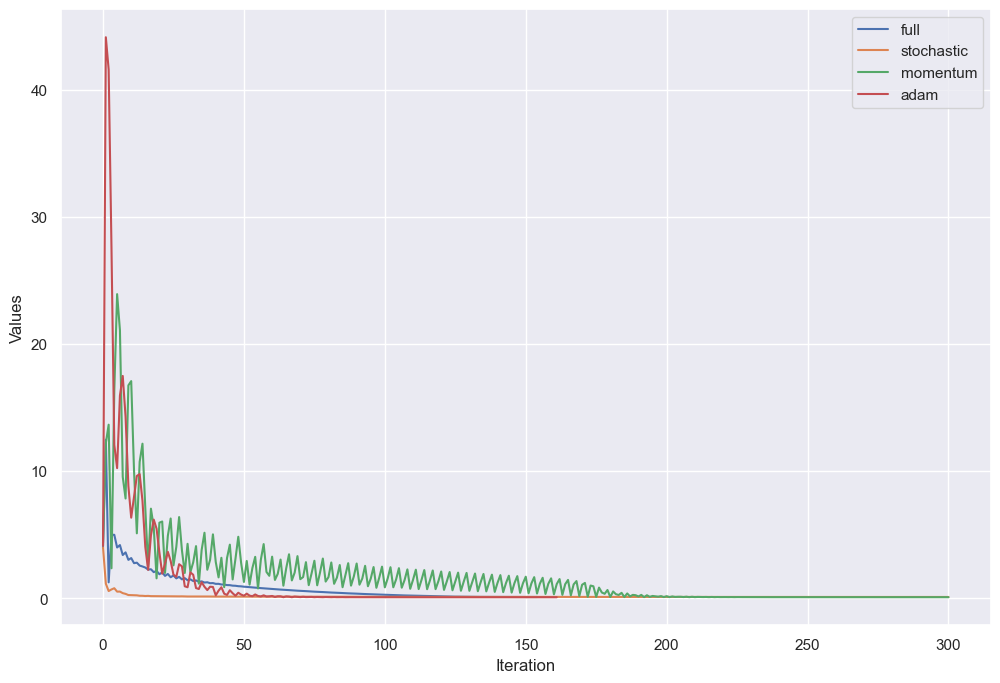

In [47]:
plt.figure(figsize=(12, 8)) 

for name, values in loss_history_logcosh.items():
    plt.plot(values, label=name)

plt.legend()

plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

#### full_logcosh

R^2 Score_train_logcosh: 0.7564634758716229

R^2 Score_test_logcosh: 0.7641885844666152

Iteration: 154

#### full_mse

R^2 Score_train_mse: 0.6818673164432989

R^2 Score_test_mse: 0.6889926065862617

Iteration: 41

#### stochastic_logcosh

R^2 Score_train_logcosh: 0.7525196210988733

R^2 Score_test_logcosh: 0.7590897645787318

Iteration: 300

#### stochastic_mse

R^2 Score_train_mse: 0.7042215641722795

R^2 Score_test_mse: 0.7080592456042477

Iteration: 110

#### momentum_logcosh

R^2 Score_train_logcosh: 0.7930607511706118

R^2 Score_test_logcosh: 0.8002372209328219

Iteration: 300


#### momentum_mse

R^2 Score_train_mse: 0.7785720066635777

R^2 Score_test_mse: 0.7849389488348384

Iteration: 88

#### adam_logcosh

R^2 Score_train_logcosh: 0.8032120428671015

R^2 Score_test_logcosh: 0.8098768025058007

Iteration: 161

#### adam_mse

R^2 Score_train_mse: 0.8004210465313126

R^2 Score_test_mse: 0.807557387762322

Iteration: 156

Оценки стало лучше, но итерации стали больше.

### Кулинарно-социализационный бонус. (0.5 балла).

Как мы знаем, осень прекрасная пора, время пробовать новое и делиться теплом с друзьями и близкими. Выберите рецепт, который соответствует вашему настроению, приготовьте выбранное блюдо и угостите хотя бы одного человека им. Кратко опишите ваши впечатления, прикрепите рецепт и фотографии блюда и довольного гостя.

Лапша по Сычуаньский, к сожалению довольный гость не хочет себя показать

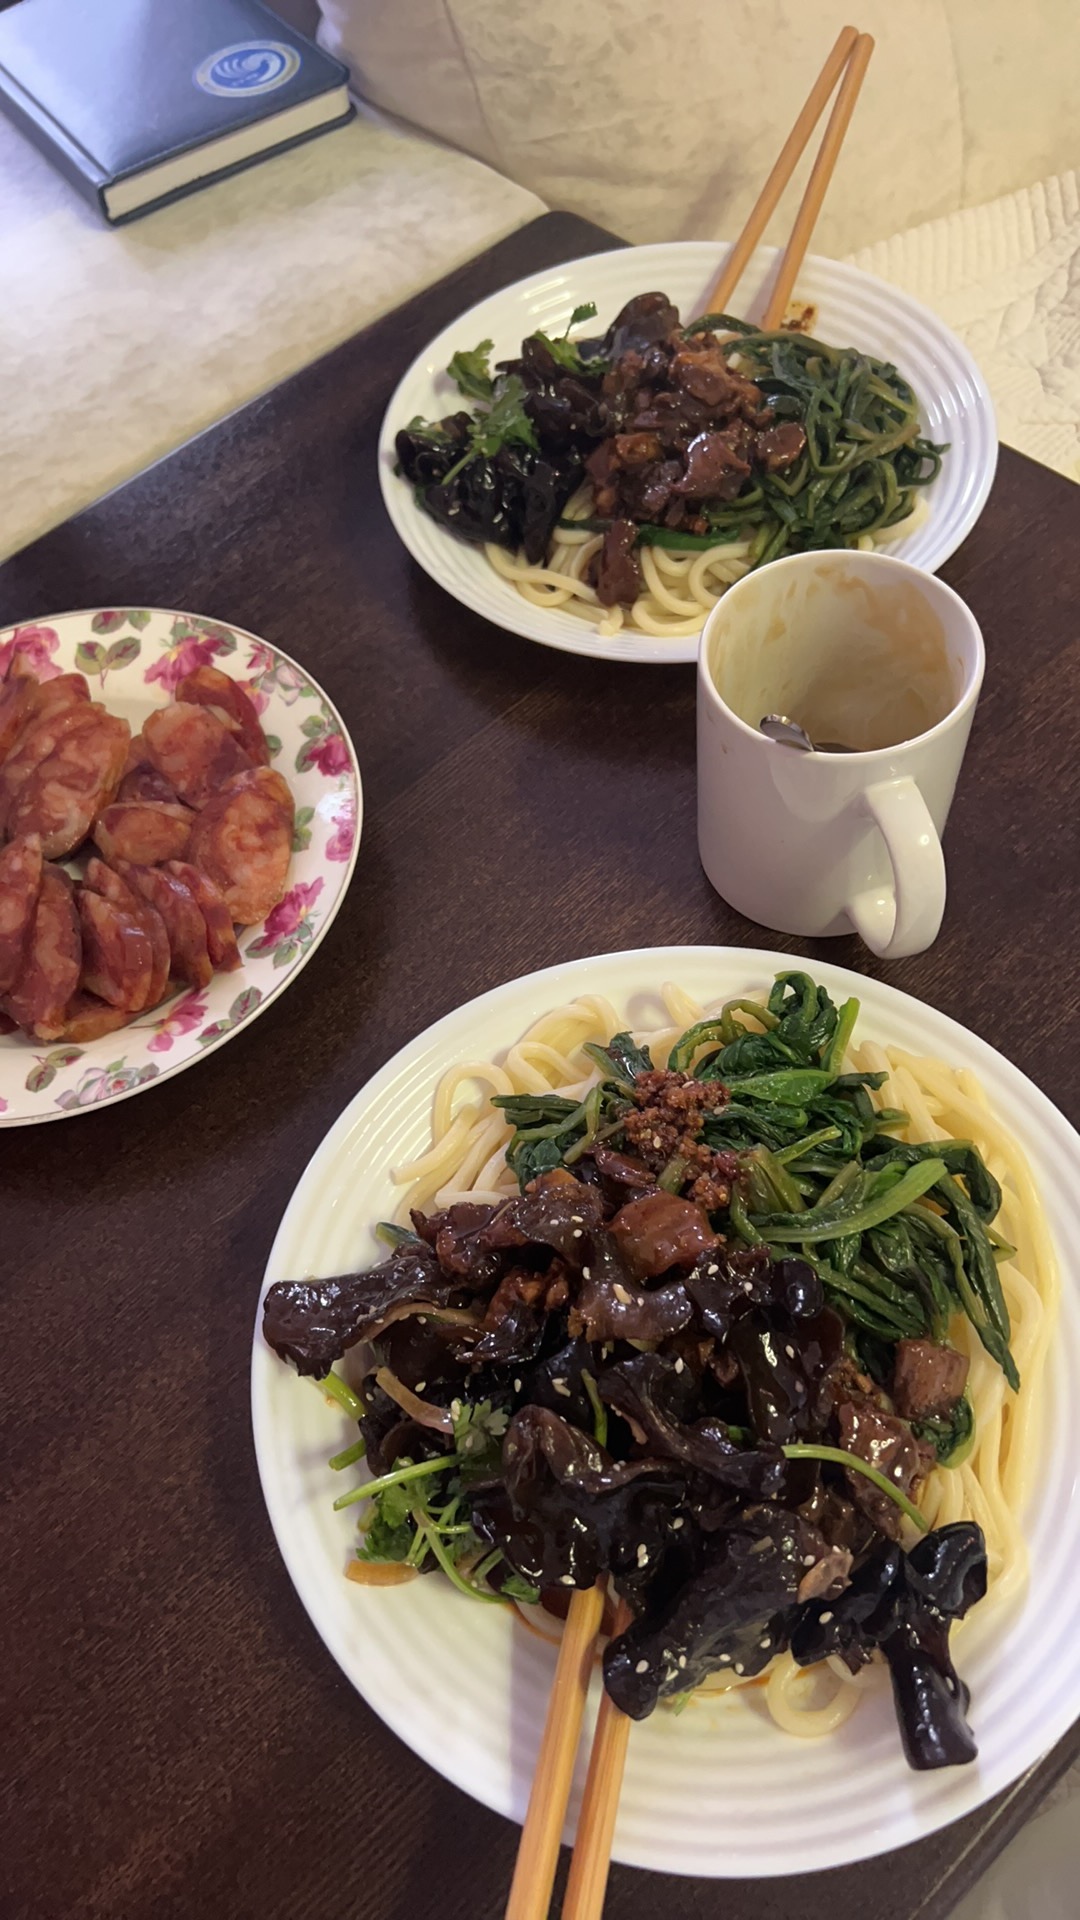

### Бонус 1. Другие методы градиентного спуска (1 балл).

По желанию выберите метод градиентного спуска из следующего списка и самостоятельно реализуйте его в файле `descents.py`. Обучите линейную регрессию с помощью этого метода, сравните с методами из основной части домашнего задания.

`AdaMax` (вариация Adam основанная на $l_{\infty}$), `Nadam` (вариация Adam совмещенная с методом импульса Нестерова), `AMSGrad` (ещё одна вариация Adam).

#### AMSGrad

In [29]:
%load_ext autoreload

%autoreload 2

import numpy as np

from descents import get_descent
from linear_regression import LinearRegression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from descents import LossFunction
from sklearn.metrics import r2_score, mean_squared_error

lambdas = np.hstack((np.array([0]), np.logspace(-6, 1, 10)))
best_lambdas_AMSGrad = {}
    
for descent_name in ['AMSGrad']:
    
    dict_ = {}
    for l in lambdas:
        descent_config = {
            'descent_name': descent_name,
            'kwargs': {
                'dimension': X_train.shape[1],
                'lambda_': l
            }
        }

        regression = LinearRegression(
            descent_config=descent_config,
        )

        regression.fit(X_train, y_train)
        y_pred = regression.predict(X_val)
        error = mean_squared_error(y_pred, y_val)
        dict_[error] = l

    best_lambdas_AMSGrad[descent_name] = dict_[min(dict_.keys(), key=abs)]
        
best_lambdas_AMSGrad

{'AMSGrad': 1.6681005372000592}

In [32]:
best_lambdas = {'full': 0.46415888336127725,
 'stochastic': 0.46415888336127725,
 'momentum': 0.46415888336127725,
 'adam': 10.0,
 'AMSGrad': 1.6681005372000592}

In [33]:
loss_history_AMSGrad = {}

for descent_name in ['full', 'stochastic', 'momentum', 'adam', 'AMSGrad']:
    
    descent_config = {
        'descent_name': descent_name,
        
        'kwargs': {
            'dimension': X_train_big.shape[1],
            'lambda_': best_lambdas[descent_name]
        }
    }

    regression = LinearRegression(
        descent_config=descent_config,
    )

    regression.fit(X_train_big, y_train_big)
    loss_history_AMSGrad[descent_name] = regression.loss_history
    y_pred = regression.predict(X_test)
    error = r2_score(y_pred, y_test)
    train_pred = regression.predict(X_train)
    error1 = r2_score(train_pred, y_train)
    print(descent_name)
    print("R^2 Score_train:", error)
    print("R^2 Score_test:", error1)
    print("Iteration:", regression.descent.lr.iteration)
    print()
    print()

full
R^2 Score_train: 0.6886332901173433
R^2 Score_test: 0.6969264268894328
Iteration: 42


stochastic
R^2 Score_train: 0.7046306558152745
R^2 Score_test: 0.7138259912618616
Iteration: 157


momentum
R^2 Score_train: 0.7822719224274567
R^2 Score_test: 0.7894903338355521
Iteration: 88


adam
R^2 Score_train: 0.8001971215362409
R^2 Score_test: 0.8071495944418383
Iteration: 145


AMSGrad
R^2 Score_train: 0.7958787659434922
R^2 Score_test: 0.8029303533052494
Iteration: 98




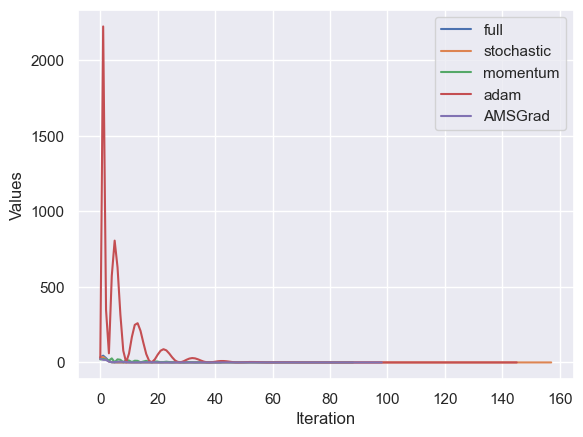

In [35]:
for name, values in loss_history_AMSGrad.items():
    plt.plot(values, label=name)

plt.legend()

plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

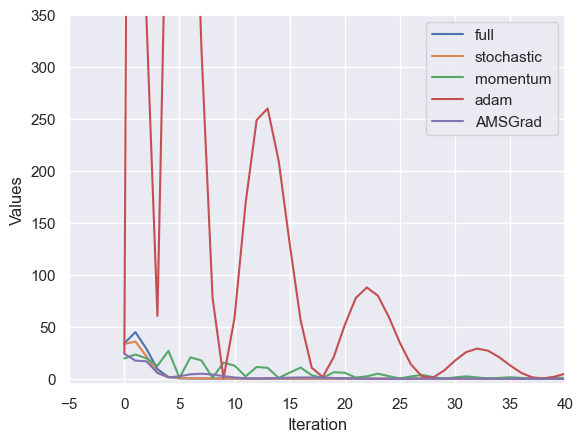

In [37]:
for name, values in loss_history_AMSGrad.items():
    plt.plot(values, label=name)

plt.legend()
plt.xlim(-5, 40)
plt.ylim(-5, 350)
plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

AMSGrad имеет лучшую оценку среди всех, и еще занимает меньше итерации

### Бонус 2. Другие функции потерь (1 балл).

Аналогично 8 заданию реализуйте две функции потерь - **MAE** и **Huber**.

Самостоятельно продифференцируйте данные функции потерь, чтобы найти их градиенты _(требуется показать не только результат, но и промежуточные вычисления)_:


#### MAE

$$
MAE = \frac{1}{n} \sum_{i=1}^n |X_iw - y_i|
$$
#### MAEGrad
$$
\frac{\partial MAE}{\partial w}
=  \frac{1}{n} \sum_{i=1}^n sign(X_iw - y_i)X_i dw = \frac{1}{n} X^T sign(Xw - y) dw
$$

#### Huber

$$
|X_iw - y_i| < \epsilon \Longrightarrow Huber = \frac{1}{n} \sum_{i=1}^n \frac{1}{2} (X_iw - y_i) ^ 2
$$

$$
|X_iw - y_i| >= \epsilon \Longrightarrow Huber = \frac{1}{n} \sum_{i=1}^n \epsilon |X_iw - y_i| - \frac{1}{2} \epsilon ^ 2
$$
#### HuberGrad
$$
|X_iw - y_i| < \epsilon \Longrightarrow \frac{\partial Huber}{\partial w} = \frac{1}{n} \sum_{i=1}^n  (X_iw - y_i)X_i dw = \frac{1}{n} X^T(Xw - y) dw
$$

$$
|X_iw - y_i| >= \epsilon \Longrightarrow \frac{\partial Huber}{\partial w}
= \frac{1}{n} \sum_{i=1}^n sign(X_iw - y_i)X_i dw
=\frac{1}{n} \epsilon X^T sign(Xw - y) dw
$$

Программно реализуйте градиентный спуск с данными функциями потерь в файле `descents.py`, обучите все четыре метода (без регуляризации) аналогично 5 заданию, сравните их качество с четырьмя методами из 5 задания.

Сравните между собой *для каждого метода отдельно* качество для разных функций потерь. Какая оказалась лучше? Как вы думаете почему?

### MAE

In [38]:
from descents import LossFunction
from sklearn.metrics import r2_score, mean_squared_error

lambdas = np.hstack((np.array([0]), np.logspace(-6, 1, 10)))
best_lambdas_AME = {}
    
for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    dict_ = {}
    for l in lambdas:
        descent_config = {
            'descent_name': descent_name,
            'kwargs': {
                'dimension': X_train.shape[1],
                'lambda_': l,
                'loss_function': LossFunction.MAE
            }
        }

        regression = LinearRegression(
            descent_config=descent_config,
        )

        regression.fit(X_train, y_train)
        y_pred = regression.predict(X_val)
        error = mean_squared_error(y_pred, y_val)
        dict_[error] = l

    best_lambdas_AME[descent_name] = dict_[min(dict_.keys(), key=abs)]
        
best_lambdas_AME

{'full': 1.6681005372000592,
 'stochastic': 1.6681005372000592,
 'momentum': 1.6681005372000592,
 'adam': 10.0}

In [40]:
loss_history_AME = {}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    descent_config = {
        'descent_name': descent_name,
        
        'kwargs': {
            'dimension': X_train_big.shape[1],
            'lambda_': best_lambdas_AME[descent_name],
            'loss_function': LossFunction.MAE
        }
    }

    regression = LinearRegression(
        descent_config=descent_config,
    )

    regression.fit(X_train_big, y_train_big)
    loss_history_AME[descent_name] = regression.loss_history
    y_pred = regression.predict(X_test)
    error = r2_score(y_pred, y_test)
    train_pred = regression.predict(X_train)
    error1 = r2_score(train_pred, y_train)
    print(descent_name)
    print("R^2 Score_train:", error)
    print("R^2 Score_test:", error1)
    print("Iteration:", regression.descent.lr.iteration)
    print()
    print()

full
R^2 Score_train: 0.7387015950644198
R^2 Score_test: 0.7445679982582951
Iteration: 60


stochastic
R^2 Score_train: 0.7646805855880272
R^2 Score_test: 0.7696317522116976
Iteration: 300


momentum
R^2 Score_train: 0.7842258284671629
R^2 Score_test: 0.7912352800303186
Iteration: 154


adam
R^2 Score_train: 0.8009074571219608
R^2 Score_test: 0.8075077404997651
Iteration: 300




### Compare with MSE

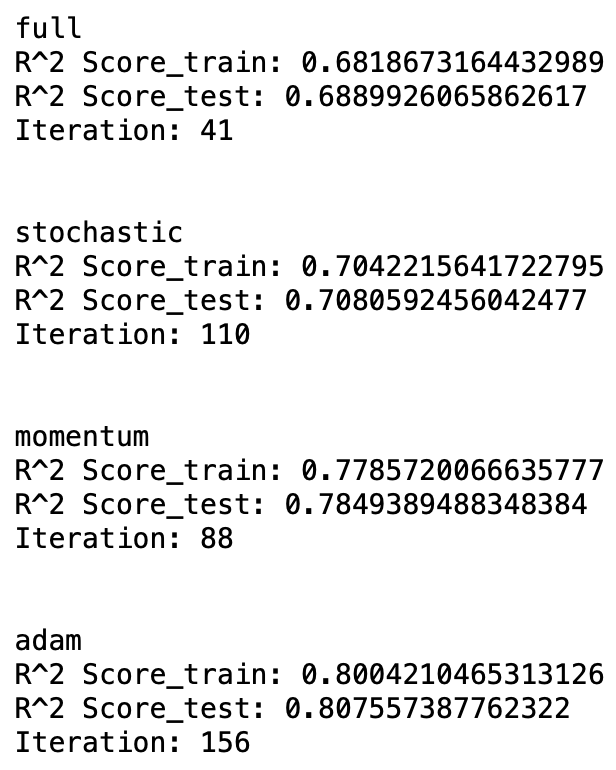

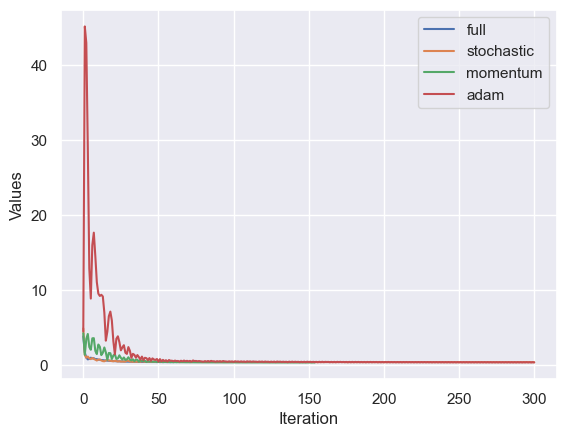

In [41]:
for name, values in loss_history_AME.items():
    plt.plot(values, label=name)

plt.legend()

plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

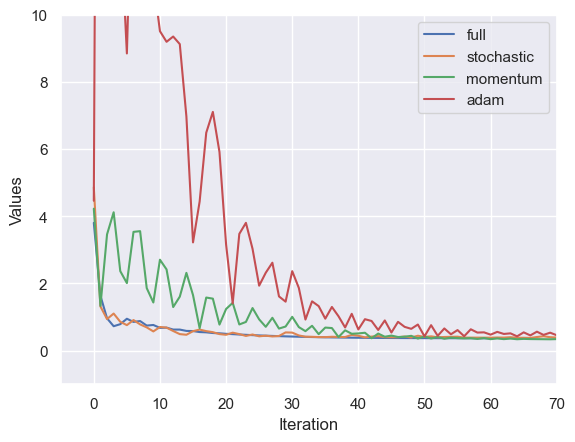

In [43]:
for name, values in loss_history_AME.items():
    plt.plot(values, label=name)

plt.legend()
plt.xlim(-5, 70)
plt.ylim(-1, 10)

plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

В целом оценки по MAE лучше чем по MSE 

### Huber

In [32]:
from descents import LossFunction
from sklearn.metrics import r2_score, mean_squared_error

lambdas = np.hstack((np.array([0]), np.logspace(-6, 2, 10)))
best_lambdas_Huber = {}
    
for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    dict_ = {}
    for l in lambdas:
        descent_config = {
            'descent_name': descent_name,
            'kwargs': {
                'dimension': X_train.shape[1],
                'lambda_': l,
                'loss_function': LossFunction.Huber
            }
        }

        regression = LinearRegression(
            descent_config=descent_config,
        )

        regression.fit(X_train, y_train)
        y_pred = regression.predict(X_val)
        error = mean_squared_error(y_pred, y_val)
        dict_[error] = l

    best_lambdas_Huber[descent_name] = dict_[min(dict_.keys(), key=abs)]
        
best_lambdas_Huber

{'full': 1.6681005372000557,
 'stochastic': 1.6681005372000557,
 'momentum': 1.6681005372000557,
 'adam': 12.915496650148826}

In [33]:
loss_history_huber = {}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    
    descent_config = {
        'descent_name': descent_name,
        
        'kwargs': {
            'dimension': X_train_big.shape[1],
            'lambda_': best_lambdas_Huber[descent_name],
            'loss_function': LossFunction.MAE
        }
    }

    regression = LinearRegression(
        descent_config=descent_config,
    )

    regression.fit(X_train_big, y_train_big)
    loss_history_huber[descent_name] = regression.loss_history
    y_pred = regression.predict(X_test)
    error = r2_score(y_pred, y_test)
    train_pred = regression.predict(X_train)
    error1 = r2_score(train_pred, y_train)
    print(descent_name)
    print("R^2 Score_train:", error)
    print("R^2 Score_test:", error1)
    print("Iteration:", regression.descent.lr.iteration)
    print()
    print()

full
R^2 Score_train: 0.7376287017754126
R^2 Score_test: 0.743231313175497
Iteration: 63


stochastic
R^2 Score_train: 0.7248157058634961
R^2 Score_test: 0.7327753001589628
Iteration: 300


momentum
R^2 Score_train: 0.7837526615161956
R^2 Score_test: 0.7913103124226846
Iteration: 151


adam
R^2 Score_train: 0.7308972593149172
R^2 Score_test: 0.7376749043640757
Iteration: 300




### Compare with MSE

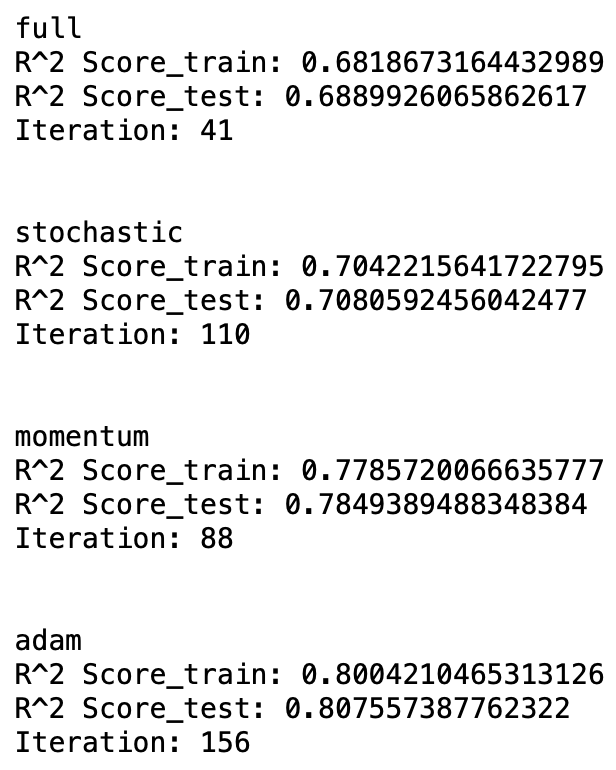

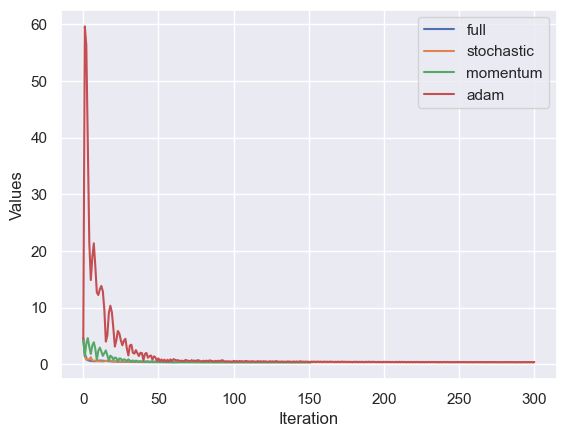

In [34]:
for name, values in loss_history_huber.items():
    plt.plot(values, label=name)

plt.legend()

plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

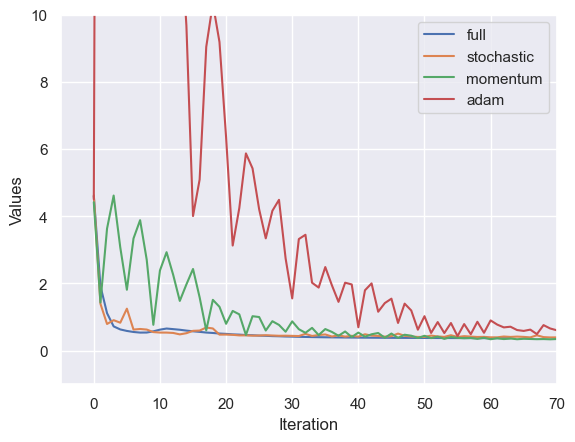

In [35]:
for name, values in loss_history_huber.items():
    plt.plot(values, label=name)

plt.legend()
plt.xlim(-5, 70)
plt.ylim(-1, 10)

plt.xlabel('Iteration')
plt.ylabel('Values')

plt.show()

Кроме Adam остальные оценки стали лучше